# Task 2 — Baseline Rule-Based per Classificazione BBC Sport / Non-Sport


## 1. Import e caricamento dati

In [ ]:
import pandas as pd
import numpy as np
from collections import Counter  # Per contare frequenze (utile per NLP)

import nltk
nltk.download('punkt_tab', quiet=True)   # Risorse per tokenizzazione
nltk.download('stopwords', quiet=True)   # Stopwords per filtrare parole comuni

from nltk.tokenize import RegexpTokenizer
from nltk import FreqDist                  # Distribuzione di frequenza
from nltk.corpus import stopwords         # Lista di stopwords

# Tokenizer basato su regex (estrae sequenze di caratteri alfanumerici, ignorando punteggiatura)
_tokenizer = RegexpTokenizer(r'\w+')


from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import matplotlib.pyplot as plt

# Caricamento del dataset CSV
df = pd.read_csv("bbc_dataset.csv")

# Informazioni base sul dataset
print(f"Dataset: {df.shape[0]} articoli, {df.shape[1]} colonne")

# Distribuzione delle classi (colonna 'label')
print(f"\nDistribuzione classi:\n{df['label'].value_counts()}")

# Visualizza le prime righe del dataset
df.head()

Dataset: 2000 articoli, 3 colonne

Distribuzione classi:
label
non_sport    1000
sport        1000
Name: count, dtype: int64


,title,text,label
0,The sweet flavours of Pinoy BBQ,"While yakitori and satay may be better known, ...",non_sport
1,Seized oil tanker leaving Scotland to head acr...,A Russian-flagged oil tanker which was seized ...,non_sport
2,Mageean 'continuing to find the joy in every day',Ciara Mageean has expressed her gratitude for ...,sport
3,Onyeama-Christie & Segun sign new Saracens deals,Saracens flanker Andy Onyeama-Christie and win...,sport
4,Minnesota Vikings receiver Moore dies aged 25,Warning: this story includes content some read...,sport


## 2. Pre-processing: tokenizzazione e rimozione stopwords

In [2]:
# Creazione dell'insieme di stopwords inglesi (set = lookup più veloce O(1))
STOP_WORDS = set(stopwords.words("english"))


def tokenizza_e_pulisci(testo: str) -> list[str]:
    """
    Tokenizza un testo con NLTK, converte in minuscolo,
    rimuove stopwords e token non alfabetici (numeri, punteggiatura).
    """
    # Tokenizzazione + lowercase
    tokens = _tokenizer.tokenize(testo.lower())

    # Pulizia dei token con filtro
    tokens_puliti = [
        t for t in tokens
        if t.isalpha()           # mantiene solo parole alfabetiche
        and t not in STOP_WORDS  # rimuove parole comuni (stopwords)
        and len(t) > 2           # rimuove token molto corti (rumore)
    ]

    return tokens_puliti


# Applichiamo la funzione a tutta la colonna "text" del DataFrame
# e salviamo il risultato in una nuova colonna "tokens"
df["tokens"] = df["text"].apply(tokenizza_e_pulisci)

print("Esempio di tokenizzazione:")
print(f"  Titolo:  {df.iloc[0]['title'][:80]}...")     # mostra parte del titolo
print(f"  Tokens:  {df.iloc[0]['tokens'][:15]}...")    # primi token del testo
print(f"  N token: {len(df.iloc[0]['tokens'])}")       # numero totale di token

Esempio di tokenizzazione:
  Titolo:  The sweet flavours of Pinoy BBQ...
  Tokens:  ['yakitori', 'satay', 'may', 'better', 'known', 'philippines', 'charcoal', 'grilled', 'delicacies', 'whose', 'distinctively', 'sweet', 'tangy', 'flavour', 'unites']...
  N token: 894


## 3. Split train/test

Dividiamo il dataset **prima** di analizzare le frequenze, così le keyword vengono estratte solo dal train set (evitando data leakage).

In [3]:
# Suddivisione del dataset in training e test set
df_train, df_test = train_test_split(
    df,
    test_size=0.2,          # 20% dei dati usati per il test
    random_state=42,        # garantisce riproducibilità dello split
    stratify=df["label"]    # mantiene la stessa distribuzione delle classi in train e test
)

# Dimensioni dei due sottoinsiemi
print(f"Train: {len(df_train)} articoli")
print(f"Test:  {len(df_test)} articoli")

# Verifica della distribuzione delle classi nel training set
print(f"\nDistribuzione train:\n{df_train['label'].value_counts()}")

# Verifica della distribuzione delle classi nel test set
print(f"\nDistribuzione test:\n{df_test['label'].value_counts()}")

Train: 1600 articoli
Test:  400 articoli

Distribuzione train:
label
sport        800
non_sport    800
Name: count, dtype: int64

Distribuzione test:
label
non_sport    200
sport        200
Name: count, dtype: int64


## 4. Analisi frequenze con FreqDist

Calcoliamo le frequenze delle parole per ciascuna classe nel **train set** e individuiamo le parole più discriminanti.

In [4]:
# Raccogliamo tutti i token per classe (solo dal train set)
tokens_sport = []
tokens_non_sport = []

# Iteriamo riga per riga sul training set
for _, riga in df_train.iterrows():
    if riga["label"] == "sport":
        tokens_sport.extend(riga["tokens"])       # aggiunge i token dell'articolo alla lista sport
    else:
        tokens_non_sport.extend(riga["tokens"])   # aggiunge i token alla lista non-sport

# Creazione delle distribuzioni di frequenza (conteggio parole)
fd_sport = FreqDist(tokens_sport)
fd_non_sport = FreqDist(tokens_non_sport)

# Statistiche sul vocabolario
print(f"Vocabolario sport:     {len(fd_sport):,} parole uniche ({len(tokens_sport):,} token totali)")
print(f"Vocabolario non-sport: {len(fd_non_sport):,} parole uniche ({len(tokens_non_sport):,} token totali)")

print("\n--- Top 15 parole SPORT ---")
# Mostra le 15 parole più frequenti nella classe sport
for parola, freq in fd_sport.most_common(15):
    print(f"  {parola:20s}  freq={freq:5d}")

print("\n--- Top 15 parole NON-SPORT ---")
# Mostra le 15 parole più frequenti nella classe non-sport
for parola, freq in fd_non_sport.most_common(15):
    print(f"  {parola:20s}  freq={freq:5d}")

Vocabolario sport:     21,348 parole uniche (234,662 token totali)
Vocabolario non-sport: 41,321 parole uniche (449,142 token totali)

--- Top 15 parole SPORT ---
  said                  freq= 1507
  year                  freq= 1420
  world                 freq= 1353
  first                 freq= 1284
  one                   freq= 1257
  time                  freq= 1158
  team                  freq= 1154
  two                   freq= 1114
  league                freq= 1023
  season                freq=  977
  last                  freq=  928
  back                  freq=  863
  sport                 freq=  843
  win                   freq=  841
  game                  freq=  793

--- Top 15 parole NON-SPORT ---
  said                  freq= 3735
  says                  freq= 2238
  one                   freq= 2195
  people                freq= 2105
  also                  freq= 1911
  like                  freq= 1455
  new                   freq= 1348
  would                 freq= 1345

## 5. Selezione parole chiave discriminanti

Per ogni parola che appare almeno 30 volte in totale, calcoliamo il **rapporto di appartenenza** alla classe sport. Le parole con rapporto molto alto (>0.85) sono keyword sport; quelle con rapporto molto basso (<0.15) sono keyword non-sport.

In [9]:
# Soglie per la selezione delle keyword
SOGLIA_FREQ_MIN = 30        # frequenza minima totale (sport + non-sport)
SOGLIA_SPORT = 0.85         # una parola è "sport" se >= 85% delle occorrenze sono in sport
SOGLIA_NON_SPORT = 0.15     # una parola è "non-sport" se <= 15% delle occorrenze sono in sport

# Unione di tutti i vocaboli (insieme delle parole presenti in almeno una classe)
vocabolario = set(fd_sport.keys()) | set(fd_non_sport.keys())

keyword_sport = set()
keyword_non_sport = set()
statistiche = []  # lista di tuple per analisi/ordinamento (parola, ratio, freq_s, freq_n)

# Analisi parola per parola
for parola in vocabolario:
    freq_s = fd_sport[parola]       # frequenza nella classe sport
    freq_n = fd_non_sport[parola]   # frequenza nella classe non-sport
    totale = freq_s + freq_n        # frequenza totale

    # Scarta parole troppo rare (rumore)
    if totale < SOGLIA_FREQ_MIN:
        continue

    # Calcolo del rapporto di appartenenza alla classe sport
    rapporto_sport = freq_s / totale

    # Classificazione della parola come keyword
    if rapporto_sport >= SOGLIA_SPORT:
        keyword_sport.add(parola)
    elif rapporto_sport <= SOGLIA_NON_SPORT:
        keyword_non_sport.add(parola)

    # Salva statistiche per analisi e stampa
    statistiche.append((parola, rapporto_sport, freq_s, freq_n))

# Ordinamento per rapporto (decrescente → più "sport" in alto)
statistiche.sort(key=lambda x: x[1], reverse=True)

print(f"Keyword SPORT selezionate: {len(keyword_sport)}")
print(f"Keyword NON-SPORT selezionate: {len(keyword_non_sport)}")

print("\n--- Top 20 keyword SPORT ---")
# Prime 20 parole con rapporto più alto (più rappresentative dello sport)
for parola, rapporto, fs, fn in statistiche[:20]:
    print(f"  {parola:20s}  ratio={rapporto:.3f}  sport={fs:5d}  non={fn:5d}")

print("\n--- Top 20 keyword NON-SPORT ---")
# Ultime 20 parole (più rappresentative del non-sport)
for parola, rapporto, fs, fn in statistiche[-20:]:
    print(f"  {parola:20s}  ratio={rapporto:.3f}  sport={fs:5d}  non={fn:5d}")

Keyword SPORT selezionate: 271
Keyword NON-SPORT selezionate: 1241

--- Top 20 keyword SPORT ---
  wiffen                ratio=1.000  sport=   31  non=    0
  hag                   ratio=1.000  sport=   30  non=    0
  europa                ratio=1.000  sport=   39  non=    0
  ufc                   ratio=1.000  sport=  107  non=    0
  benfica               ratio=1.000  sport=   46  non=    0
  dedicatedfootball     ratio=1.000  sport=   30  non=    0
  lando                 ratio=1.000  sport=   44  non=    0
  vinicius              ratio=1.000  sport=   63  non=    0
  amorim                ratio=1.000  sport=  198  non=    0
  flament               ratio=1.000  sport=   30  non=    0
  mctominay             ratio=1.000  sport=   39  non=    0
  wimbledon             ratio=1.000  sport=   39  non=    0
  mma                   ratio=1.000  sport=   30  non=    0
  bulls                 ratio=1.000  sport=   38  non=    0
  gerwen                ratio=1.000  sport=   40  non=    0
  e

## 6. Classificatore Rule-Based

Il classificatore conta quante keyword sport e non-sport compaiono nel testo. Se il punteggio sport è maggiore, predice `sport`; altrimenti `non_sport`.

In [10]:
def classificatore_rule_based(tokens: list[str],
                              kw_sport: set,
                              kw_non_sport: set) -> str:
    """
    Classificatore basato su parole chiave.

    Per ogni token nel testo:
      - se è una keyword sport      → punteggio_sport += 1
      - se è una keyword non-sport → punteggio_non_sport += 1

    Se punteggio_sport > punteggio_non_sport → 'sport'
    Altrimenti → 'non_sport' (default)
    """

    # Conta quante parole del testo appartengono alle keyword sport
    punteggio_sport = sum(1 for t in tokens if t in kw_sport)

    # Conta quante parole appartengono alle keyword non-sport
    punteggio_non_sport = sum(1 for t in tokens if t in kw_non_sport)

    # Decisione finale basata sul confronto dei punteggi
    if punteggio_sport > punteggio_non_sport:
        return "sport"
    else:
        return "non_sport"   # caso di pareggio incluso (default)


# Applichiamo il classificatore al test set
df_test = df_test.copy()  # evita modifiche al DataFrame originale

df_test["predizione"] = df_test["tokens"].apply(
    lambda t: classificatore_rule_based(t, keyword_sport, keyword_non_sport)
)

# Mostriamo alcuni esempi di predizione
print("Esempi di predizione:")
for _, riga in df_test.head(10).iterrows():
    ok = "✓" if riga["predizione"] == riga["label"] else "✗"  # confronto predizione vs vero
    print(f"  {ok} vero={riga['label']:10s}  pred={riga['predizione']:10s}  titolo={riga['title'][:60]}")

Esempi di predizione:
  ✓ vero=non_sport   pred=non_sport   titolo=An Irish pub expert's top five in Dublin
  ✓ vero=non_sport   pred=non_sport   titolo=SpaceX pulls off Starship rocket launch in much-needed comeb
  ✓ vero=sport       pred=sport       titolo=Snoop Dogg's surreal Swansea visit heralds late drama
  ✓ vero=non_sport   pred=non_sport   titolo=Sussan Ley and the glass cliff: Does Australian politics sti
  ✓ vero=non_sport   pred=non_sport   titolo=We gave an AI a Rorschach test. What it saw in the inkblots 
  ✓ vero=sport       pred=sport       titolo=GB '25 years' behind world's best in short track
  ✓ vero=sport       pred=sport       titolo=Hull claims fifth European title with victory in Riyadh
  ✓ vero=non_sport   pred=non_sport   titolo=Parents alarmed after schools named in violent post
  ✓ vero=non_sport   pred=non_sport   titolo=Fact-checking White House plaques targeting former US presid
  ✓ vero=sport       pred=sport       titolo=Bellamy aims high after Wales' N

## 7. Valutazione con scikit-learn

In [12]:
# Etichette vere (ground truth) e predette dal modello
y_true = df_test["label"]
y_pred = df_test["predizione"]

# ── Classification Report ──
# Mostra metriche principali: precision, recall, f1-score e support per ciascuna classe
# target_names specifica l'ordine/nomi delle classi nel report
print(classification_report(y_true, y_pred, target_names=["non_sport", "sport"]))

              precision    recall  f1-score   support

   non_sport       0.93      0.99      0.96       200
       sport       0.99      0.93      0.96       200

    accuracy                           0.96       400
   macro avg       0.96      0.96      0.96       400
weighted avg       0.96      0.96      0.96       400



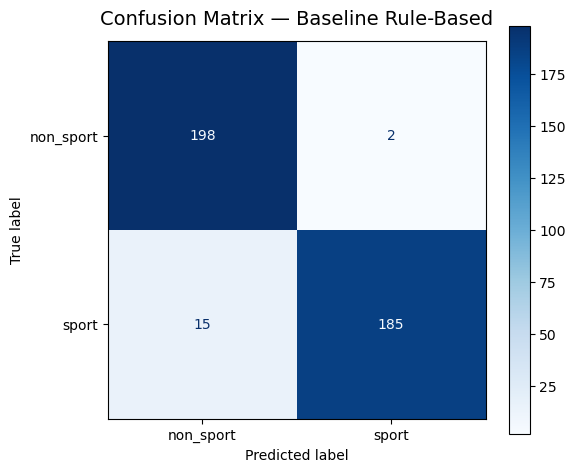

In [13]:
import os

# ── Confusion Matrix ──
# Calcolo della matrice di confusione tra valori reali e predetti
cm = confusion_matrix(y_true, y_pred, labels=["non_sport", "sport"])

# Creazione figura
fig, ax = plt.subplots(figsize=(6, 5))

# Visualizzazione della confusion matrix con etichette e formato interi
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["non_sport", "sport"])
disp.plot(cmap="Blues", ax=ax, values_format="d")

# Titolo del grafico
ax.set_title("Confusion Matrix — Baseline Rule-Based", fontsize=14, pad=12)

plt.tight_layout()

# Creazione cartella output se non esiste
os.makedirs("output", exist_ok=True)

# Salvataggio immagine della confusion matrix
plt.savefig("output/confusion_matrix_baseline.png", dpi=150)

# Visualizzazione a schermo
plt.show()

### Interpretazione del risultato (F1 = 0.96)

- Il dataset è **molto bilanciato** (1000 sport + 1000 non_sport) e **linguisticamente molto distinto**: gli articoli sportivi contengono nomi di squadre, punteggi, gerghi tecnici assenti negli altri.
- Le 271 keyword sport (rapporto ≥ 0.85) e le 1241 keyword non_sport (rapporto ≤ 0.15) catturano quasi perfettamente questo segnale.
- **Asimmetria**: `sport` ha recall 0.93 ma `non_sport` recall 0.99. Motivo: nel tie-break il classificatore predice `non_sport` di default → articoli sportivi con poche keyword vengono assegnati alla classe di default.
- **Limite di questo approccio**:
  - Dipende fortemente dalla scelta della soglia (0.85 / 0.15): se il dataset cambia o contiene argomenti borderline (es. un articolo sulla finanza del calcio), il rule-based fallisce.
  - Non generalizza: una parola non vista al training non contribuisce, anche se semanticamente affine (es. *Juventus* al training, *Inter* al test).
